# Final Project

#### Imports

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import pandas as pd
import string
import time
import os
from datetime import datetime

# Use GPU if available, fall back to CPU otherwise
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#### Loading Dataset
b) Download the EMNIST dataset. Note that it contains 6 variants, so called splits, which differ in size and contents. For the first half of the project, you should be using the ‘letters’ split. After loading the dataset, plot a random selection of image samples and the corresponding labels (similar to Figure 1.).

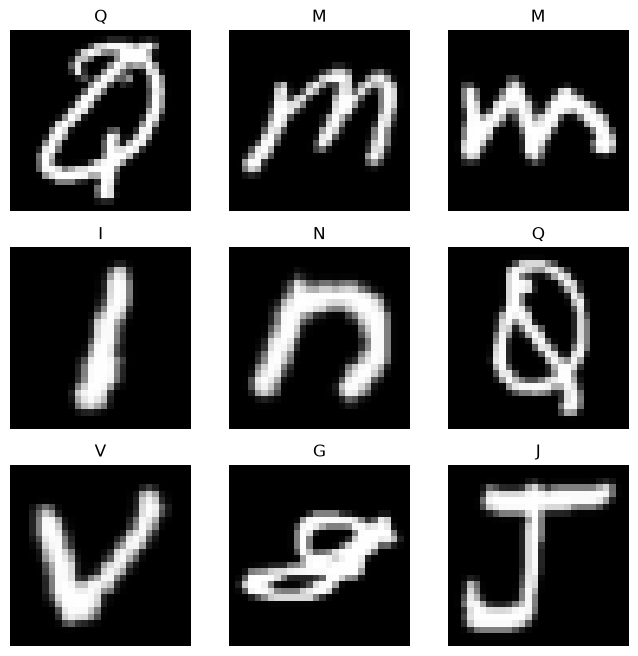

In [4]:
training_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

letters = ["N/A"] + list(string.ascii_uppercase)

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(letters[label])
    plt.axis("off")
    plt.imshow(img.squeeze().T, cmap="gray")
plt.show()

#### Basic learning functionality
c) Implement a program that defines the simple CNN model depicted in see Figure 2. and trains letter classification on the loaded dataset from step b). Implement two functions that use the given model and respective dataset for training and testing. Using cross entropy loss can be a convenient loss function, since it does not require normalized input. In addition, your program should visualize (plot) the training loss and record the total training time.

##### Create Data Loader

In [5]:
batch_size = 512

training_loader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
)


##### Define CNN

In [ ]:
class Model:
    def __init__(self, model, learning_rate, batch_size, description="simple-cnn", device=device):
        self.device = device
        self.model = model.to(self.device)
        self.criterion = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.layers = sum(1 for _ in self.model.modules()) - 1
        self.description = description

    # TRAINING FUNCTION
    def train(self, loader):
        self.model.train()

        running_loss = 0
        batch_losses = []

        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device) - 1

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            batch_losses.append(loss.item())

        average_loss = running_loss / len(loader)

        return average_loss, batch_losses

    # TESTING FUNCTION
    def test(self, loader):
        self.model.eval()

        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device) - 1

                outputs = self.model(images)
                predictions = outputs.argmax(dim=1)

                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        return accuracy

    # SAVE MODEL HELPER FUNCTION
    def save_model(self, loss_history=None, epochs=0, accuracy=None, model_dir="models", figs_dir="figs", show_plot=False):
        os.makedirs(model_dir, exist_ok=True)
        os.makedirs(figs_dir, exist_ok=True)

        timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
        acc_part = f"_acc{accuracy:.2f}" if accuracy is not None else ""

        base_name = (
            f"cnn_{self.description}"
            f"_epo{epochs}"
            f"_lr{self.learning_rate}"
            f"_bs{self.batch_size}"
            f"_lay{self.layers}"
            f"_optAdam"
            f"{acc_part}"
            f"_{timestamp}"
        )

        model_path = os.path.join(model_dir, base_name + ".pth")
        torch.save(self.model.state_dict(), model_path)
        print(f"Model saved to: {model_path}")

        if loss_history is not None and epochs != 0:
            fig_path = os.path.join(figs_dir, base_name + "_loss_history.png")
            save_loss_plot(loss_history, filename=fig_path, show_plot=show_plot)
            print(f"Plot saved to: {fig_path}")

        return model_path

##### Loss Function and Optimizer

In [7]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

##### Training Loop

In [ ]:
def training_loop(model, epochs, train_loader, test_loader, verbose=True):
    loss_history = []

    start_time = time.time()

    for epoch in range(epochs):
        avg_loss, batch_losses = model.train(train_loader)
        loss_history.append(batch_losses)

        accuracy = model.test(test_loader)

        if verbose:
            print(
                f"Epoch {epoch+1}/{epochs}  "
                f"Loss {avg_loss:.4f}  "
                f"Accuracy {accuracy:.2f}%"
            )

    training_time = time.time() - start_time

    if verbose:
        print(f"\nTraining time: {training_time:.2f} seconds")

    return loss_history, training_time


Epoch 1/5
Loss 1.3965
Accuracy 71.61%
Epoch 2/5
Loss 0.9032
Accuracy 76.29%
Epoch 3/5
Loss 0.7525
Accuracy 79.98%
Epoch 4/5
Loss 0.6426
Accuracy 81.97%
Epoch 5/5
Loss 0.5716
Accuracy 83.71%

Training time: 171.63 seconds


##### Training Loss Plot

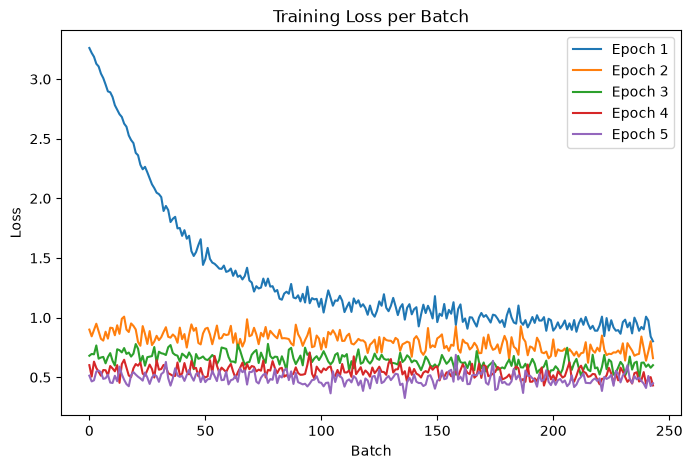

In [ ]:
def save_loss_plot(loss_history, filename, show_plot=False):
    plt.figure(figsize=(8, 5))

    for epoch, losses in enumerate(loss_history):
        plt.plot(losses, label=f"Epoch {epoch+1}")

    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.title("Training Loss per Batch")
    plt.legend()
    plt.savefig(filename)

    if show_plot:
        plt.show()
    else:
        plt.close()
